In [1]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

In [2]:
width = 21
height = 21

directions = [
    (0, -2),   # 上
    (2, 0),    # 右
    (0, 2),    # 下
    (-2, 0),   # 左
]


def can_dig(x, y, maze):
    h, w = maze.shape

    return (
        1 <= x < w - 1
        and 1 <= y < h - 1
        and maze[y, x] == 1
    )


def generate_maze(width, height, delay=0.1):
    if width < 5 or height < 5:
        raise ValueError("幅と高さは5以上にしてください")

    if width % 2 == 0 or height % 2 == 0:
        raise ValueError("幅と高さは奇数にしてください")

    # 1: 壁、0: 通路
    maze = np.ones((height, width), dtype=np.int8)

    start_x, start_y = 1, 1
    goal_x, goal_y = width - 2, height - 2

    # スタートだけを最初に掘る
    maze[start_y, start_x] = 0

    stack = [(start_x, start_y)]

    fig, ax = plt.subplots(figsize=(7, 7))

    image = ax.imshow(
        maze,
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.scatter(
        start_x,
        start_y,
        c="green",
        s=100,
        label="Start",
        zorder=3,
    )

    ax.scatter(
        goal_x,
        goal_y,
        c="red",
        s=100,
        label="Goal",
        zorder=3,
    )

    # 現在掘っている位置
    current_plot = ax.scatter(
        start_x,
        start_y,
        c="blue",
        s=50,
        label="Current",
        zorder=4,
    )

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

    while stack:
        now_x, now_y = stack[-1]

        shuffled_directions = directions.copy()
        random.shuffle(shuffled_directions)

        moved = False

        for dx, dy in shuffled_directions:
            next_x = now_x + dx
            next_y = now_y + dy

            if can_dig(next_x, next_y, maze):
                wall_x = now_x + dx // 2
                wall_y = now_y + dy // 2

                maze[wall_y, wall_x] = 0
                maze[next_y, next_x] = 0

                stack.append((next_x, next_y))
                moved = True

                current_plot.set_offsets([[next_x, next_y]])

                break

        if not moved:
            stack.pop()

            if stack:
                back_x, back_y = stack[-1]
                current_plot.set_offsets([[back_x, back_y]])

        # 同じ出力欄を更新
        image.set_data(maze)
        fig.canvas.draw()

        clear_output(wait=True)
        display(fig)

        time.sleep(delay)

    clear_output(wait=True)

    # 最終状態を表示
    current_plot.remove()
    image.set_data(maze)
    display(fig)

    plt.close(fig)

    return maze, (start_x, start_y), (goal_x, goal_y)

In [3]:
from collections import deque
import numpy as np


def check_maze(maze, start, goal):
    h, w = maze.shape

    queue = deque([start])
    visited = {start}

    directions_1step = [
        (0, -1),
        (1, 0),
        (0, 1),
        (-1, 0),
    ]

    while queue:
        x, y = queue.popleft()

        for dx, dy in directions_1step:
            next_x = x + dx
            next_y = y + dy

            if not (0 <= next_x < w and 0 <= next_y < h):
                continue

            if maze[next_y, next_x] == 1:
                continue

            if (next_x, next_y) in visited:
                continue

            visited.add((next_x, next_y))
            queue.append((next_x, next_y))

    passage_count = int(np.sum(maze == 0))
    reachable_count = len(visited)

    print(f"通路の総数: {passage_count}")
    print(f"スタートから到達できる通路数: {reachable_count}")
    print(f"ゴール到達可能: {goal in visited}")
    print(f"全通路が連結: {passage_count == reachable_count}")


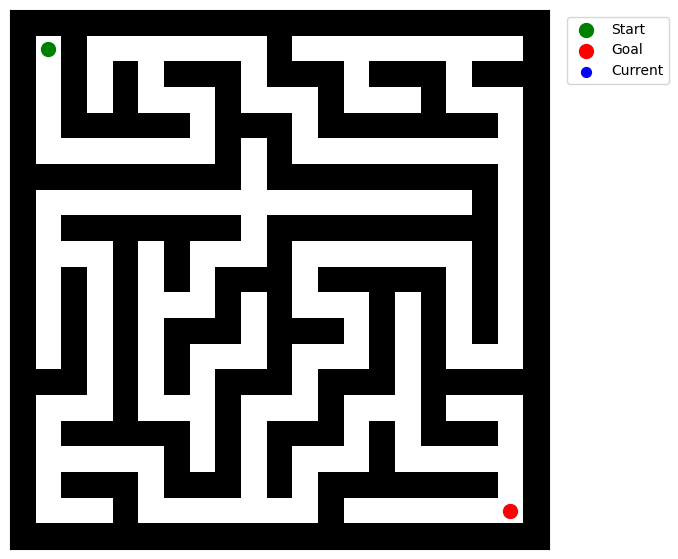

通路の総数: 199
スタートから到達できる通路数: 199
ゴール到達可能: True
全通路が連結: True


In [4]:
maze, start, goal = generate_maze(21, 21, delay=0.001)
check_maze(maze, start, goal)

In [6]:
def check_perfect_maze(maze, start, goal):
    h, w = maze.shape

    passage_count = int(np.sum(maze == 0))
    edge_count = 0

    for y in range(h):
        for x in range(w):
            if maze[y, x] != 0:
                continue

            # 右隣との接続
            if x + 1 < w and maze[y, x + 1] == 0:
                edge_count += 1

            # 下隣との接続
            if y + 1 < h and maze[y + 1, x] == 0:
                edge_count += 1

    queue = deque([start])
    visited = {start}

    for_search = [
        (0, -1),
        (1, 0),
        (0, 1),
        (-1, 0),
    ]

    while queue:
        x, y = queue.popleft()

        for dx, dy in for_search:
            next_x = x + dx
            next_y = y + dy

            if (
                0 <= next_x < w
                and 0 <= next_y < h
                and maze[next_y, next_x] == 0
                and (next_x, next_y) not in visited
            ):
                visited.add((next_x, next_y))
                queue.append((next_x, next_y))

    all_connected = len(visited) == passage_count
    no_loop = edge_count == passage_count - 1

    print(f"通路マス数: {passage_count}")
    print(f"通路間の接続数: {edge_count}")
    print(f"全通路が連結: {all_connected}")
    print(f"ループなし: {no_loop}")
    print(f"完全迷路: {all_connected and no_loop}")
    print(f"ゴール到達可能: {goal in visited}")

check_perfect_maze(maze, start, goal)

通路マス数: 199
通路間の接続数: 198
全通路が連結: True
ループなし: True
完全迷路: True
ゴール到達可能: True
